In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from hadrana.c2pt.c2pt_io import load_c2pt_raw
from hadrana.c2pt.compute_c2pt import compute_c2pt_jkn_fwd_bwd_avg
from hadrana.momenta import *


[0.62279333 0.60001834 0.50422739 ... 0.61184855 0.56303007 0.60503135]


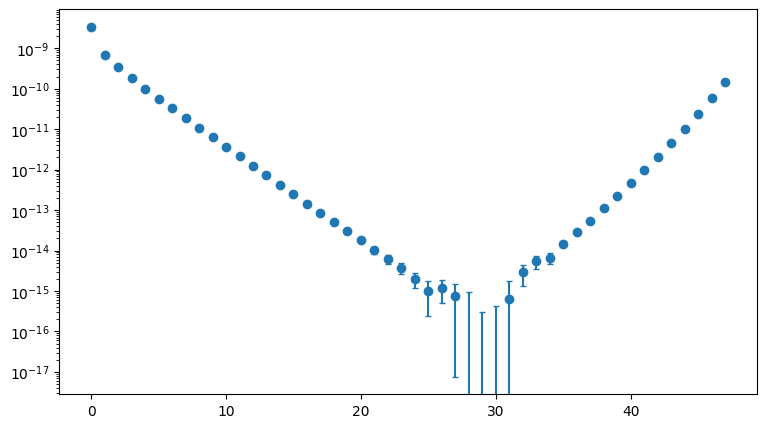

In [17]:
ensemble = "A654"
nsquare = 0
binsize = 2

base = f"/hdd/data/ensemble_data/{ensemble}" 
file = f"{base}/{ensemble}_jkn_binsize{binsize}.h5"

with h5py.File(file, "r") as f:
    mraw = f[f"/c2pt/momsq{nsquare}/resamples"][()]
    mrwfs = f["/rwf_raw"][()]

ncfg = mraw.shape[0]
ntmp = mraw.shape[1]

x = np.arange(ntmp)
mavg = np.mean(mraw, axis=0)
merr = np.sqrt(ncfg - 1) * np.std(mraw, axis=0, ddof=0)

fig, axs = plt.subplots(1, 1, figsize = (9, 5))

axs.errorbar(
    x,
    mavg,
    merr,
    fmt="o",
    capsize=2,
)

axs.set_yscale("log")

print(mrwfs)

In [18]:
print(5.050936464186033259e-01 * 1.233025475979170116e+00)
print(5.057102147647440926e-01 * 1.236988011995526993e+00)

0.622793333789353
0.6255574732076717


In [19]:
from hadrana.loader import load_rwfs
from hadrana.statistics import generate_jackknife_resamples
from hadrana.ensembles.helpers import EnsembleHelpers

def compute_c2pt_jkn_fwd_bwd_avg(ensemble: str, nsquare: int, binsize: int) -> np.ndarray:
    h = EnsembleHelpers(ensemble)
    exceptionals: np.ndarray = h.get_exceptionals()

    print(f"{ensemble}: Exceptional configs {exceptionals}")

    rwfs, rwfs_path = load_rwfs(ensemble) 
    print(f"Loading rwfs from {rwfs_path}")
    print(f"dim(rwfs) BEFORE exceptional removal: {rwfs.shape}")

    rwfs = np.delete(rwfs, exceptionals, axis=0)
    print(f"dim(rwfs) AFTER exceptional removal: {rwfs.shape}")


    c2pt_fwd: np.ndarray = load_c2pt_raw(ensemble, nsquare, "fwd")
    print(f"dim(c2pt_fwd) BEFORE exceptional removal: {c2pt_fwd.shape}")
    c2pt_bwd: np.ndarray = load_c2pt_raw(ensemble, nsquare, "bwd")
    print(f"dim(c2pt_bwd) BEFORE exceptional removal: {c2pt_bwd.shape}")

    c2pt_fwd = np.delete(c2pt_fwd, exceptionals, axis=0)
    print(f"dim(c2pt_fwd) AFTER exceptional removal: {c2pt_fwd.shape}")
    c2pt_bwd = np.delete(c2pt_bwd, exceptionals, axis=0)
    print(f"dim(c2pt_bwd) AFTER exceptional removal: {c2pt_bwd.shape}")

    # compute forward-backward average
    c2pt_fwd_bwd_avg = 0.5 * (c2pt_fwd + c2pt_bwd)  # (n_cfg, n_src, n_mom, n_time)
    print(f"dim(c2pt_fwd_bwd_avg): {c2pt_fwd_bwd_avg.shape}")

    # average over source ids and momenta
    c2pt = np.mean(c2pt_fwd_bwd_avg, axis=(1,2)) # (n_cfg, n_time)
    print(f"dim(c2pt_src_mom_avg): {c2pt.shape}")

    c2pt_jkn_fwd_bwd_avg = generate_jackknife_resamples(c2pt, rwfs, binsize)

    print(f"dim(c2pt_jkn): {c2pt_jkn_fwd_bwd_avg.shape}")

    return c2pt_jkn_fwd_bwd_avg, rwfs

In [20]:
# craw, crwfs = compute_c2pt_jkn_fwd_bwd_avg("A650", nsquare, binsize)

# ncfg = craw.shape[0]
# ntmp = craw.shape[1]

# x = np.arange(ntmp)
# cavg = np.mean(craw, axis=0)
# cerr = np.sqrt(ncfg - 1) * np.std(craw, axis=0, ddof=0)

In [21]:
# if np.array_equal(crwfs, mrwfs):
#     print("Equal")
# else:
#     print("Unequal")

# fig, axs = plt.subplots(1, 1, figsize = (9, 5))

# axs.errorbar(
#     x,
#     cavg,
#     cerr,
#     fmt="o",
#     capsize=2,
# )

# axs.set_yscale("log")

In [22]:
print(5062 // 100)

50


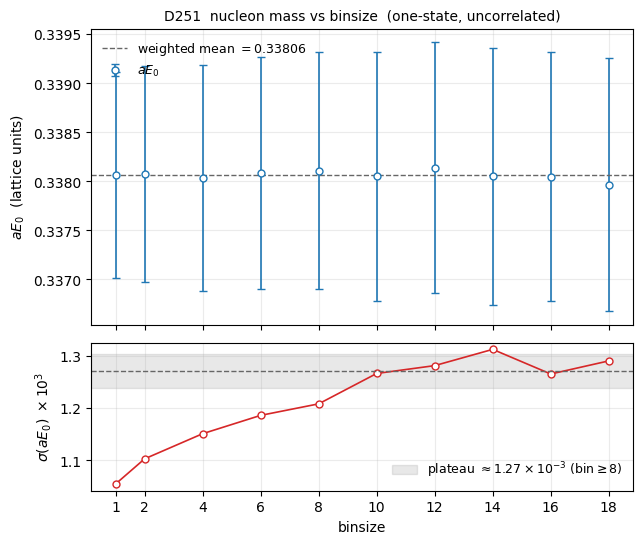

In [23]:
# --- data from the run (one-state, uncorrelated) ---
binsize = np.array([1, 2, 4, 6, 8, 10, 12, 14, 16, 18])
# E0      = np.array([3.380649e-1, 3.380722e-1, 3.380327e-1, 3.380876e-1, 3.381096e-1,
#                     3.381388e-1, 3.382096e-1, 3.381285e-1, 3.381249e-1, 3.380485e-1])
# E0_err  = np.array([1.055e-3, 1.103e-3, 1.151e-3, 1.186e-3, 1.208e-3,
#                     1.130e-3, 1.132e-3, 1.177e-3, 1.139e-3, 1.160e-3])

# FIXED WINDOW
E0      = np.array([3.380649e-1, 3.380722e-1, 3.380327e-1, 3.380876e-1, 3.381096e-1,
                    3.380511e-1, 3.381393e-1, 3.380518e-1, 3.380502e-1, 3.379641e-1])
E0_err  = np.array([1.055e-3, 1.103e-3, 1.151e-3, 1.186e-3, 1.208e-3,
                    1.266e-3, 1.281e-3, 1.312e-3, 1.265e-3, 1.290e-3])

# plateau estimated from binsize >= 8
plateau_mask = binsize >= 8
plateau_err  = E0_err[plateau_mask].mean()

fig, (ax_m, ax_e) = plt.subplots(
    2, 1, figsize=(7, 6), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
)

# --- top: nucleon mass vs binsize ---
ax_m.errorbar(binsize, E0, yerr=E0_err, fmt="o", ms=5, capsize=3,
              color="#1f77b4", mfc="white", mec="#1f77b4", lw=1.2, label=r"$aE_0$")
wmean = np.average(E0, weights=1.0 / E0_err**2)
ax_m.axhline(wmean, ls="--", lw=1, color="0.4",
             label=fr"weighted mean $= {wmean:.5f}$")
ax_m.set_ylabel(r"$aE_0$  (lattice units)")
ax_m.legend(frameon=False, fontsize=9, loc="upper left")
ax_m.set_title("D251  nucleon mass vs binsize  (one-state, uncorrelated)", fontsize=10)

# --- bottom: jackknife error vs binsize (the saturation story) ---
ax_e.plot(binsize, E0_err * 1e3, "o-", ms=5, color="#d62728",
          mfc="white", mec="#d62728", lw=1.2)
ax_e.axhline(plateau_err * 1e3, ls="--", lw=1, color="0.4")
ax_e.axhspan((plateau_err - E0_err[plateau_mask].std()) * 1e3,
             (plateau_err + E0_err[plateau_mask].std()) * 1e3,
             color="0.4", alpha=0.15,
             label=fr"plateau $\approx {plateau_err*1e3:.2f}\times10^{{-3}}$ (bin$\geq$8)")
ax_e.set_xlabel("binsize")
ax_e.set_ylabel(r"$\sigma(aE_0)\ \times 10^{3}$")
ax_e.legend(frameon=False, fontsize=9, loc="lower right")

for ax in (ax_m, ax_e):
    ax.grid(alpha=0.25)
    ax.set_xticks(binsize)

plt.show()

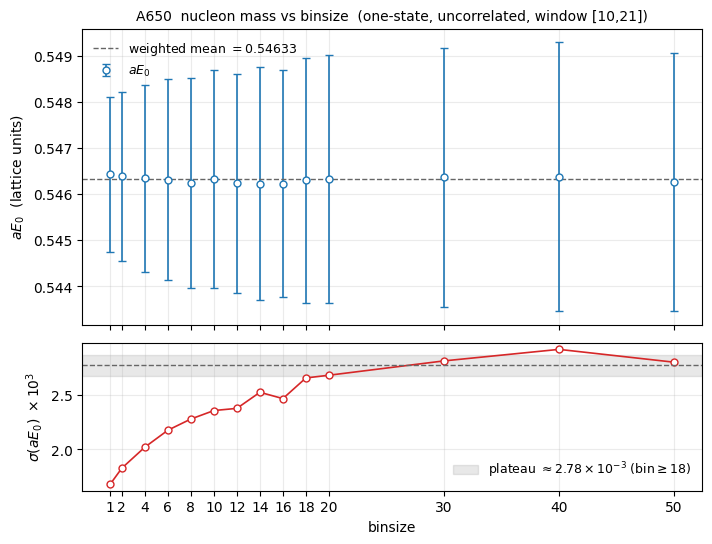

In [25]:
# --- A650 fixed-window [10,21] (one-state, uncorrelated) ---
binsize = np.array([1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 30, 40, 50])
E0      = np.array([5.464293e-1, 5.463901e-1, 5.463422e-1, 5.463178e-1, 5.462504e-1,
                    5.463326e-1, 5.462345e-1, 5.462323e-1, 5.462312e-1, 5.462998e-1,
                    5.463296e-1, 5.463675e-1, 5.463788e-1, 5.462692e-1])
E0_err  = np.array([1.682e-3, 1.828e-3, 2.021e-3, 2.177e-3, 2.280e-3,
                    2.358e-3, 2.378e-3, 2.526e-3, 2.468e-3, 2.658e-3,
                    2.683e-3, 2.815e-3, 2.921e-3, 2.803e-3])

# plateau estimated from binsize >= 18
plateau_mask = binsize >= 18
plateau_err  = E0_err[plateau_mask].mean()
plateau_std  = E0_err[plateau_mask].std()

fig, (ax_m, ax_e) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
)

# --- top: nucleon mass vs binsize ---
ax_m.errorbar(binsize, E0, yerr=E0_err, fmt="o", ms=5, capsize=3,
              color="#1f77b4", mfc="white", mec="#1f77b4", lw=1.2, label=r"$aE_0$")
wmean = np.average(E0, weights=1.0 / E0_err**2)
ax_m.axhline(wmean, ls="--", lw=1, color="0.4",
             label=fr"weighted mean $= {wmean:.5f}$")
ax_m.set_ylabel(r"$aE_0$  (lattice units)")
ax_m.legend(frameon=False, fontsize=9, loc="upper left")
ax_m.set_title("A650  nucleon mass vs binsize  (one-state, uncorrelated, window [10,21])",
               fontsize=10)

# --- bottom: jackknife error vs binsize (saturation) ---
ax_e.plot(binsize, E0_err * 1e3, "o-", ms=5, color="#d62728",
          mfc="white", mec="#d62728", lw=1.2)
ax_e.axhline(plateau_err * 1e3, ls="--", lw=1, color="0.4")
ax_e.axhspan((plateau_err - plateau_std) * 1e3, (plateau_err + plateau_std) * 1e3,
             color="0.4", alpha=0.15,
             label=fr"plateau $\approx {plateau_err*1e3:.2f}\times10^{{-3}}$ (bin$\geq$18)")
ax_e.set_xlabel("binsize")
ax_e.set_ylabel(r"$\sigma(aE_0)\ \times 10^{3}$")
ax_e.legend(frameon=False, fontsize=9, loc="lower right")

for ax in (ax_m, ax_e):
    ax.grid(alpha=0.25)
    ax.set_xticks(binsize)
ax_e.tick_params(axis="x", labelrotation=0)

plt.show()

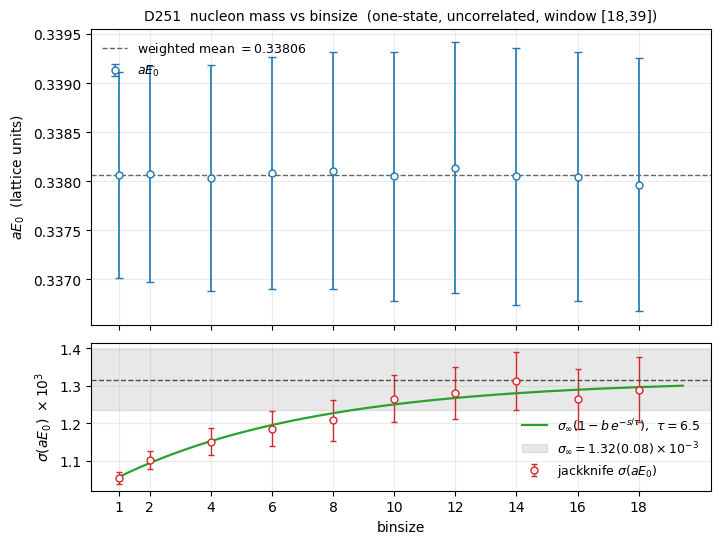

D251:  aE0 = 0.3381(13)   sigma_inf = 1.316(0.082)e-3,  tau = 6.54


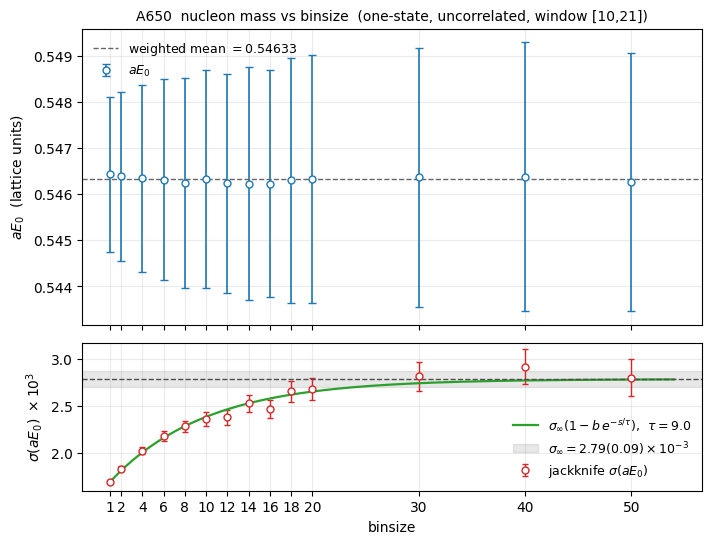

A650:  aE0 = 0.5463(28)   sigma_inf = 2.787(0.090)e-3,  tau = 9.01


(np.float64(0.0027867411073755526),
 np.float64(8.964077389163941e-05),
 np.float64(9.012554531275185))

In [31]:
import numpy as np
import gvar as gv
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sat_model(s, sigma_inf, b, tau):
    """Error rises from below toward sigma_inf as bins decorrelate."""
    return sigma_inf * (1.0 - b * np.exp(-s / tau))

def plot_binsize_saturation(ensemble, binsize, E0, E0_err, ncfg, window):
    binsize = np.asarray(binsize, float)
    E0      = np.asarray(E0, float)
    E0_err  = np.asarray(E0_err, float)

    # error-on-error: relative ~ 1/sqrt(2 N_bins), N_bins = ncfg / s
    n_bins     = ncfg / binsize
    err_on_err = E0_err / np.sqrt(2.0 * n_bins)

    # weighted saturation fit
    p0     = [E0_err.max() * 1.05, 0.4, 5.0]
    bounds = ([0, 0, 0.1], [np.inf, 1.0, 1e3])
    popt, pcov = curve_fit(sat_model, binsize, E0_err, p0=p0,
                           sigma=err_on_err, absolute_sigma=True,
                           bounds=bounds, maxfev=40000)
    sigma_inf, b, tau = popt
    sigma_inf_err     = np.sqrt(np.diag(pcov))[0]

    s_grid = np.linspace(binsize.min(), binsize.max() * 1.08, 300)
    fit    = sat_model(s_grid, *popt)

    fig, (ax_m, ax_e) = plt.subplots(
        2, 1, figsize=(8, 6), sharex=True,
        gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
    )

    # --- top: mass flatness ---
    ax_m.errorbar(binsize, E0, yerr=E0_err, fmt="o", ms=5, capsize=3,
                  color="#1f77b4", mfc="white", mec="#1f77b4", lw=1.2, label=r"$aE_0$")
    wmean = np.average(E0, weights=1.0 / E0_err**2)
    ax_m.axhline(wmean, ls="--", lw=1, color="0.4",
                 label=fr"weighted mean $= {wmean:.5f}$")
    ax_m.set_ylabel(r"$aE_0$  (lattice units)")
    ax_m.legend(frameon=False, fontsize=9, loc="upper left")
    ax_m.set_title(f"{ensemble}  nucleon mass vs binsize  "
                   f"(one-state, uncorrelated, window {window})", fontsize=10)

    # --- bottom: error saturation + fit ---
    ax_e.errorbar(binsize, E0_err * 1e3, yerr=err_on_err * 1e3, fmt="o", ms=5,
                  capsize=2, color="#d62728", mfc="white", mec="#d62728", lw=1.0,
                  label="jackknife $\\sigma(aE_0)$")
    ax_e.plot(s_grid, fit * 1e3, "-", lw=1.6, color="#2ca02c",
              label=fr"$\sigma_\infty(1-b\,e^{{-s/\tau}})$,  $\tau={tau:.1f}$")
    ax_e.axhline(sigma_inf * 1e3, ls="--", lw=1, color="0.3")
    ax_e.axhspan((sigma_inf - sigma_inf_err) * 1e3, (sigma_inf + sigma_inf_err) * 1e3,
                 color="0.4", alpha=0.15,
                 label=fr"$\sigma_\infty = {sigma_inf*1e3:.2f}({sigma_inf_err*1e3:.2f})\times10^{{-3}}$")
    ax_e.set_xlabel("binsize")
    ax_e.set_ylabel(r"$\sigma(aE_0)\ \times 10^{3}$")
    ax_e.legend(frameon=False, fontsize=9, loc="lower right")

    for ax in (ax_m, ax_e):
        ax.grid(alpha=0.25)
        ax.set_xticks(binsize)

    plt.show()
    aE0 = gv.gvar(wmean, sigma_inf)        # error is sigma_inf (lattice units), not *1e3
    print(f"{ensemble}:  aE0 = {aE0}   "
      f"sigma_inf = {sigma_inf*1e3:.3f}({sigma_inf_err*1e3:.3f})e-3,  tau = {tau:.2f}")
    return sigma_inf, sigma_inf_err, tau

# ---------------- D251 ----------------
d251_bin = [1, 2, 4, 6, 8, 10, 12, 14, 16, 18]
d251_E0  = [3.380649e-1, 3.380722e-1, 3.380327e-1, 3.380876e-1, 3.381096e-1,
            3.380511e-1, 3.381393e-1, 3.380518e-1, 3.380502e-1, 3.379641e-1]
d251_err = [1.055e-3, 1.103e-3, 1.151e-3, 1.186e-3, 1.208e-3,
            1.266e-3, 1.281e-3, 1.312e-3, 1.265e-3, 1.290e-3]
plot_binsize_saturation("D251", d251_bin, d251_E0, d251_err, ncfg=2012, window="[18,39]")

# ---------------- A650 ----------------
a650_bin = [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 30, 40, 50]
a650_E0  = [5.464293e-1, 5.463901e-1, 5.463422e-1, 5.463178e-1, 5.462504e-1,
            5.463326e-1, 5.462345e-1, 5.462323e-1, 5.462312e-1, 5.462998e-1,
            5.463296e-1, 5.463675e-1, 5.463788e-1, 5.462692e-1]
a650_err = [1.682e-3, 1.828e-3, 2.021e-3, 2.177e-3, 2.280e-3,
            2.358e-3, 2.378e-3, 2.526e-3, 2.468e-3, 2.658e-3,
            2.683e-3, 2.815e-3, 2.921e-3, 2.803e-3]
plot_binsize_saturation("A650", a650_bin, a650_E0, a650_err, ncfg=5062, window="[10,21]")

/tmp/ipykernel_532853/245390953.py:3: RuntimeWarning: invalid value encountered in log
  return np.log(c[:-1] / c[1:])


NameError: name 'cavg' is not defined

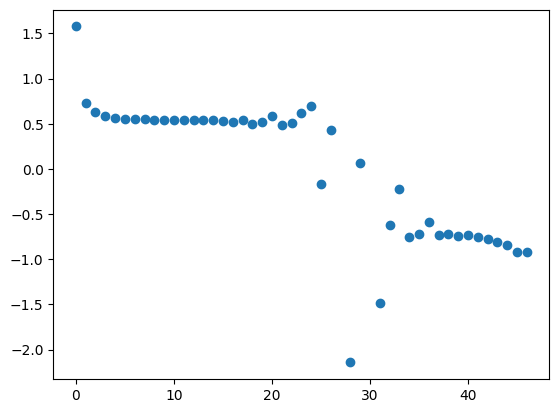

In [24]:
def meff(c):
    c = np.asarray(c)
    return np.log(c[:-1] / c[1:])

plt.plot(meff(mavg), "o", label="marcel")
plt.plot(meff(cavg), "s", label="chris")
plt.legend()

nsquare=0  (binsize=2, nt=48)
------------------------------------------------------------------------------
    t |        fwd C   fwd SNR |        avg C   avg SNR | SNR avg/fwd
    0 |    3.254e-11    249.95 |    3.255e-11    250.41 |       1.002
    1 |    2.827e-12     85.61 |    2.837e-12    114.74 |       1.340
    2 |    7.618e-13     42.67 |    7.679e-13     61.37 |       1.438
    3 |    2.384e-13     23.40 |    2.451e-13     33.27 |       1.422
    4 |    9.719e-14     15.11 |    9.353e-14     21.27 |       1.407
    5 |    3.109e-14      6.86 |    2.661e-14      8.38 |       1.222
    6 |    1.436e-14      4.59 |    9.965e-15      4.34 |       0.948
    7 |    6.285e-15      3.14 |    5.744e-15      3.72 |       1.184
    8 |    2.113e-15      1.45 |    1.758e-15      1.56 |       1.071
    9 |    6.501e-16      0.56 |   -2.987e-17     -0.04 |      -0.062
   10 |    7.202e-16      0.89 |    9.618e-16      1.52 |       1.706
   11 |    1.182e-15      1.76 |    4.335e-16      

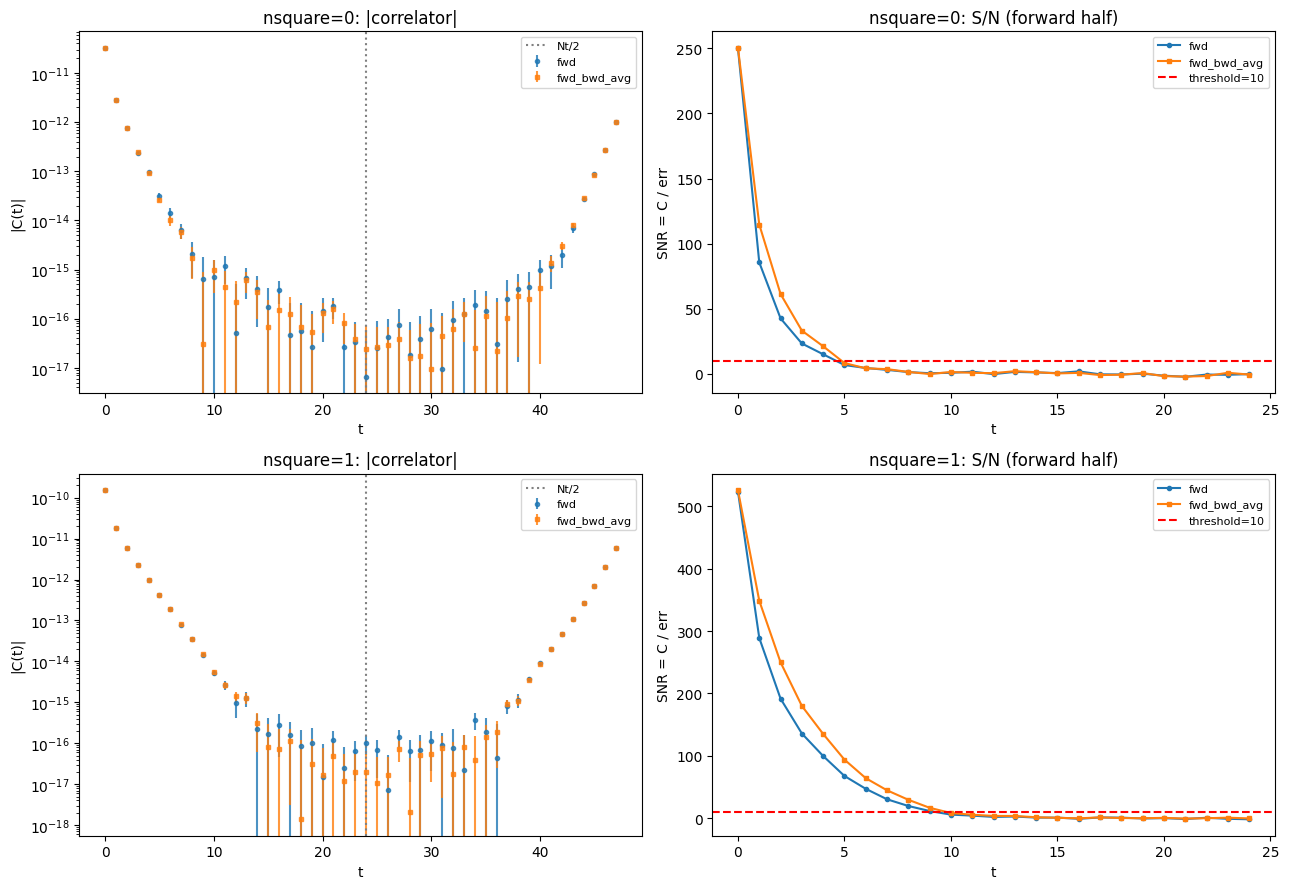

In [ ]:
#!/usr/bin/env python3
"""
Settle whether `fwd_bwd_avg` is a proper FOLD or a diluting average.
 
Reads both pre-exported jackknife datasets for a shell:
    /c2pt/nsquare{ns}/fwd            (forward only)
    /c2pt/nsquare{ns}/fwd_bwd_avg    (0.5 * (fwd + bwd) as built in compute_c2pt.py)
 
A proper fold averages two independent FULL-signal estimates of the same decay,
so at small t it should improve S/N by ~sqrt(2) (ratio avg/fwd ~ 1.41) and give a
LATER (or equal) t_max than fwd alone.
 
If `bwd` is NOT time-reversed before the add, then at small t the forward signal
is averaged against the backward branch's NOISE FLOOR: the mean is ~halved and the
variance grows, so S/N gets WORSE and fwd alone yields a later t_max. In that case
the fwd_bwd_avg dataset is hurting you and you should fold properly or fit `fwd`.
"""
import h5py
import numpy as np
import matplotlib.pyplot as plt
 
from chigrad.statistics import compute_sdev   # same convention as the fit pipeline
 
# ----------------------------------------------------------------------
ensemble      = "A654"
binsize       = 2
shells        = [0, 1]          # the starved low shells; add more if you like
resample_type = "jackknife"
snr_threshold = 10
small_t_band  = (1, 5)          # forward-signal region used for the verdict
# ----------------------------------------------------------------------
 
path = (f"/hdd/data/ensemble_data/{ensemble}/c2pt/"
        f"{ensemble}_c2pt_binsize{binsize:02d}_jkn.h5")
 
 
def summarize(y):
    """jackknife central value, error (pipeline convention), and S/N per t."""
    cen = np.mean(y, axis=0)
    err = compute_sdev(y, resample_type)
    snr = cen / err
    return cen, err, snr
 
 
def t_max_like(snr, threshold=snr_threshold):
    """replicate estimate_maximum_timeslice: first t with SNR<=thr, minus one."""
    half  = len(snr) // 2
    below = np.where(snr[:half] <= threshold)[0]
    return int(below[0] - 1) if below.size else half - 1
 
 
fig, axes = plt.subplots(len(shells), 2, figsize=(13, 4.5 * len(shells)),
                         squeeze=False)
 
for row, ns in enumerate(shells):
    with h5py.File(path, "r") as f:
        fwd  = f[f"/c2pt/nsquare{ns:02d}/fwd"][()]
        favg = f[f"/c2pt/nsquare{ns:02d}/fwd_bwd_avg"][()]
 
    fwd_cen, fwd_err, fwd_snr = summarize(fwd)
    avg_cen, avg_err, avg_snr = summarize(favg)
 
    nt   = fwd_cen.shape[0]
    half = nt // 2
 
    tmax_fwd = t_max_like(fwd_snr)
    tmax_avg = t_max_like(avg_snr)
 
    lo, hi = small_t_band
    band   = np.arange(lo, hi + 1)
    # mean S/N ratio in the forward band (convention-independent)
    ratio_band = float(np.mean(avg_snr[band] / fwd_snr[band]))
 
    # ---- printed table -------------------------------------------------
    print("=" * 78)
    print(f"nsquare={ns}  (binsize={binsize}, nt={nt})")
    print("-" * 78)
    print(f"  {'t':>3s} | {'fwd C':>12s} {'fwd SNR':>9s} | "
          f"{'avg C':>12s} {'avg SNR':>9s} | {'SNR avg/fwd':>11s}")
    for t in range(0, half + 1):
        r = avg_snr[t] / fwd_snr[t] if fwd_snr[t] != 0 else np.nan
        print(f"  {t:3d} | {fwd_cen[t]:12.3e} {fwd_snr[t]:9.2f} | "
              f"{avg_cen[t]:12.3e} {avg_snr[t]:9.2f} | {r:11.3f}")
    print("-" * 78)
    print(f"  t_max(SNR<= {snr_threshold}):   fwd = {tmax_fwd}    "
          f"fwd_bwd_avg = {tmax_avg}")
    print(f"  mean SNR ratio (avg/fwd) over t in [{lo},{hi}] = {ratio_band:.3f}")
 
    # ---- verdict heuristic --------------------------------------------
    if ratio_band >= 1.25 and tmax_avg >= tmax_fwd:
        verdict = ("PROPER FOLD: avg ~sqrt(2) better at small t and t_max not "
                   "worse. bwd is reversed; keep using fwd_bwd_avg.")
    elif ratio_band <= 0.9 or tmax_fwd > tmax_avg:
        verdict = ("DILUTION: avg is WORSE at small t / fwd reaches later t_max. "
                   "bwd is NOT reversed before the add -> fold properly "
                   "(0.5*(C(t)+C(Nt-t))) or just fit the `fwd` dataset.")
    else:
        verdict = ("AMBIGUOUS: ratio between sqrt(2) and 1. Inspect the table and "
                   "the plot; bwd may be partially aligned or signal too weak.")
    print(f"  VERDICT: {verdict}")
    print("=" * 78 + "\n")
 
    # ---- plots ---------------------------------------------------------
    t = np.arange(nt)
    axL, axR = axes[row]
 
    axL.errorbar(t, np.abs(fwd_cen), yerr=fwd_err, fmt="o", ms=3,
                 label="fwd", alpha=0.8)
    axL.errorbar(t, np.abs(avg_cen), yerr=avg_err, fmt="s", ms=3,
                 label="fwd_bwd_avg", alpha=0.8)
    axL.set_yscale("log")
    axL.axvline(half, ls=":", color="grey", label="Nt/2")
    axL.set_xlabel("t")
    axL.set_ylabel("|C(t)|")
    axL.set_title(f"nsquare={ns}: |correlator|")
    axL.legend(fontsize=8)
 
    axR.plot(t[:half + 1], fwd_snr[:half + 1], "o-", ms=3, label="fwd")
    axR.plot(t[:half + 1], avg_snr[:half + 1], "s-", ms=3, label="fwd_bwd_avg")
    axR.axhline(snr_threshold, ls="--", color="red",
                label=f"threshold={snr_threshold}")
    axR.set_xlabel("t")
    axR.set_ylabel("SNR = C / err")
    axR.set_title(f"nsquare={ns}: S/N (forward half)")
    axR.legend(fontsize=8)
 
fig.tight_layout()
# out = f"fold_check_{ensemble}_binsize{binsize:02d}.png"
# fig.savefig(out, dpi=130)